# Trabalho Prático: Mineração de Dados para Previsão de Sobrevivência de Pacientes com Cirrose

**Disciplina:** Inteligência de Negócios (2026/1)  
**Professora:** Kelly Assis de Souza Gazolli  
**Alunos:** Gustavo Saraiva Mariano e Pedro Renã da Silva Moreira

---
## 1. Importação de Bibliotecas e Dependências
Neste bloco inicial, realizamos a instalação e a importação de todas as ferramentas necessárias para o desenvolvimento do projeto:
* **Manipulação e Visualização de Dados:** `pandas`, `numpy`, `matplotlib` e `seaborn`.
* **Machine Learning (Scikit-Learn):** Divisão dos dados (`train_test_split`), métricas de avaliação e o classificador `KNeighborsClassifier`.
* **Algoritmos de Ensemble e Boosting:** `RandomForestClassifier` e `XGBClassifier`.
* **Balanceamento de Dados:** Biblioteca `imblearn` para aplicação da técnica SMOTE.


In [56]:
# instalação das dependências no ambiente Jupyter Notebook
!pip install -q scikit-learn imbalanced-learn xgboost seaborn joblib ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, precision_score, recall_score, f1_score, classification_report, accuracy_score)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from ucimlrepo import fetch_ucirepo

## 2. Carga do Conjunto de Dados
Carregamento do arquivo original obtido a partir do repositório UCI Machine Learning (https://archive.ics.uci.edu/dataset/878/cirrhosis+patient+survival+prediction+dataset-1).

In [57]:
cirrose = fetch_ucirepo(id=878)
df = cirrose.data.original

print(df.value_counts("Status"))
print(f"Dimensões do dataset: {df.shape}")
df.head()

Status
C     232
D     161
CL     25
Name: count, dtype: int64
Dimensões do dataset: (418, 20)


,ID,N_Days,Status,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,1,400,D,D-penicillamine,21464,F,Y,Y,Y,Y,14.5,261,2.60,156,1718.0,137.95,172,190,12.2,4.0
1,2,4500,C,D-penicillamine,20617,F,N,Y,Y,N,1.1,302,4.14,54,7394.8,113.52,88,221,10.6,3.0
2,3,1012,D,D-penicillamine,25594,M,N,N,N,S,1.4,176,3.48,210,516.0,96.10,55,151,12.0,4.0
3,4,1925,D,D-penicillamine,19994,F,N,Y,Y,S,1.8,244,2.54,64,6121.8,60.63,92,183,10.3,4.0
4,5,1504,CL,Placebo,13918,F,N,Y,Y,N,3.4,279,3.53,143,671.0,113.15,72,136,10.9,3.0


## 3. Pré-processamento e Tratamento dos Dados
Esta etapa realiza o tratamento necessário para preparar a base de dados para os classificadores:
1. **Tratamento de Dados Ausentes (Inputação):** Preenchimento de valores nulos utilizando a mediana para os atributos numéricos e a moda para os atributos categóricos.
2. **Codificação Categórica (One-Hot Encoding):** Transformação das variáveis qualitativas em atributos binários (*dummies*).
3. **Mapeamento da Variável Alvo:** Conversão das categorias de sobrevivência do paciente (`C`: Censurado, `CL`: Transplante, `D`: Óbito) em valores numéricos (`0`, `1` e `2`).

In [58]:
from sklearn.impute import SimpleImputer

label_col = "Status"

numeric_cols = ["Age", "Bilirubin", "Cholesterol", "Albumin", "Copper", "Alk_Phos", "SGOT", "Tryglicerides", "Platelets", "Prothrombin"]
categorical_cols = ["Drug", "Sex", "Ascites", "Hepatomegaly", "Spiders", "Edema"]

# 1) limpeza das strings e nulos
# Força numéricos a serem float e transforma erros em NaN real
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

for col in categorical_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace(['nan', 'NaNN', 'NaN', 'None', 'null', ''], np.nan)

# 2) tratamento dos valores ausentes usando o SimpleImputer
imputer_numeric = SimpleImputer(strategy="median")
imputer_categorical = SimpleImputer(strategy="most_frequent")

df[numeric_cols] = imputer_numeric.fit_transform(df[numeric_cols])
df[categorical_cols] = imputer_categorical.fit_transform(df[categorical_cols])

# 3) Conversão das variáveis categóricas usando One-Hot Encoding
df_encoded = pd.get_dummies(df[numeric_cols + categorical_cols], columns=categorical_cols, drop_first=True)

# 4) mapeamento da variável/label ("status") para formato númerico
target_map = {"C": 0, "CL": 1, "D": 2}
df["Target"] = df[label_col].map(target_map)

#garantia da integridade dos índices e da remoção dos nulos (sem o problema da coluna)
df_encoded = df_encoded.dropna()
y = df.loc[df_encoded.index, "Target"].astype(int)
X = df_encoded.astype(float)

feature_cols = X.columns.tolist()

print("Atributos usados:", len(feature_cols))
print("Formato final de X:", X.shape)

Atributos usados: 17
Formato final de X: (418, 17)


In [59]:
print(X.columns.to_list())


['Age', 'Bilirubin', 'Cholesterol', 'Albumin', 'Copper', 'Alk_Phos', 'SGOT', 'Tryglicerides', 'Platelets', 'Prothrombin', 'Drug_Placebo', 'Sex_M', 'Ascites_Y', 'Hepatomegaly_Y', 'Spiders_Y', 'Edema_S', 'Edema_Y']


## 4. Divisão entre Treinamento e Teste
Separação do conjunto de dados seguindo a proporção exata determinada no escopo do projeto: **70% para treinamento** e **30% para teste**. O parâmetro `stratify=y` garante que a proporção das classes se mantenha idêntica em ambas as partições.

In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=13,
    stratify=y
)

print(f"Quantidade de amostras para Treino: {X_train.shape[0]}")
print(f"Quantidade de amostras para Teste: {X_test.shape[0]}")

Quantidade de amostras para Treino: 292
Quantidade de amostras para Teste: 126


## 5. Experimento 1: Classificação com a Base Original (Desbalanceada)
Execução do processo de classificação utilizando a distribuição original dos dados. Serão testados os três algoritmos propostos, avaliando suas respectivas Matrizes de Confusão, Acurácia, Precisão, Revocação e F1-Score. O parâmetro `zero_division=0` foi adotado para tratar os relatórios nos cenários em que classes minoritárias não recebem predições.

In [61]:
# K-Nearest Neighbors (KKN)
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

print(f"\n{'='*40}")
print("KNN – Base Original")
print("confusion matrix")
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred_knn):.5f}")

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(f"\n{'='*40}")
print("RANDOM FOREST – Base Original")
print("confusion matrix")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf):.5f}")

#XGBoost
xgb = XGBClassifier()
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

print(f"\n{'='*40}")
print("XGBOOST – Base Original")
print("confusion matrix")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb):.5f}")


KNN – Base Original
confusion matrix
[[57  0 13]
 [ 6  1  1]
 [30  1 17]]
              precision    recall  f1-score   support

           0       0.61      0.81      0.70        70
           1       0.50      0.12      0.20         8
           2       0.55      0.35      0.43        48

    accuracy                           0.60       126
   macro avg       0.55      0.43      0.44       126
weighted avg       0.58      0.60      0.57       126

Acurácia: 0.59524

RANDOM FOREST – Base Original
confusion matrix
[[59  0 11]
 [ 5  1  2]
 [15  0 33]]
              precision    recall  f1-score   support

           0       0.75      0.84      0.79        70
           1       1.00      0.12      0.22         8
           2       0.72      0.69      0.70        48

    accuracy                           0.74       126
   macro avg       0.82      0.55      0.57       126
weighted avg       0.75      0.74      0.72       126

Acurácia: 0.73810

XGBOOST – Base Original
confusion matrix


## 6. Experimento 2: Balanceamento por SMOTE e Classificação
Para contornar o severo desbalanceamento de classes, aplica-se a técnica **SMOTE** (*Synthetic Minority Over-sampling Technique*) **exclusivamente sobre os dados de treinamento**. Em seguida, os mesmos três algoritmos são reavaliados para medir o impacto da amostragem artificial sobre o desempenho preditivo das classes minoritárias.

In [62]:
# balanceamento dos dados usando o SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nDistribuição após SMOTE:")
print(pd.Series(y_train_smote).value_counts())

# 1. KNN com SMOTE
knn_smote = KNeighborsClassifier()
knn_smote.fit(X_train_smote, y_train_smote)
y_pred_knn_smote = knn_smote.predict(X_test)

print(f"\n{'='*40}")
print("KNN – SMOTE")
print("confusion matrix")
print(confusion_matrix(y_test, y_pred_knn_smote))
print(classification_report(y_test, y_pred_knn_smote, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred_knn_smote):.5f}")

# 2. RANDOM FOREST com SMOTE
rf_smote = RandomForestClassifier()
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_rf_smote = rf_smote.predict(X_test)

print(f"\n{'='*40}")
print("RANDOM FOREST – SMOTE")
print("confusion matrix")
print(confusion_matrix(y_test, y_pred_rf_smote))
print(classification_report(y_test, y_pred_rf_smote, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred_rf_smote):.5f}")

# 3. XGBOOST com SMOTE
xgb_smote = XGBClassifier()
xgb_smote.fit(X_train_smote, y_train_smote)
y_pred_xgb_smote = xgb_smote.predict(X_test)

print(f"\n{'='*40}")
print("XGBOOST – SMOTE")
print("confusion matrix")
print(confusion_matrix(y_test, y_pred_xgb_smote))
print(classification_report(y_test, y_pred_xgb_smote, zero_division=0))
print(f"Acurácia: {accuracy_score(y_test, y_pred_xgb_smote):.5f}")


Distribuição após SMOTE:
Target
0    162
1    162
2    162
Name: count, dtype: int64

KNN – SMOTE
confusion matrix
[[31 16 23]
 [ 3  4  1]
 [17  4 27]]
              precision    recall  f1-score   support

           0       0.61      0.44      0.51        70
           1       0.17      0.50      0.25         8
           2       0.53      0.56      0.55        48

    accuracy                           0.49       126
   macro avg       0.43      0.50      0.44       126
weighted avg       0.55      0.49      0.51       126

Acurácia: 0.49206

RANDOM FOREST – SMOTE
confusion matrix
[[54  5 11]
 [ 4  2  2]
 [15  0 33]]
              precision    recall  f1-score   support

           0       0.74      0.77      0.76        70
           1       0.29      0.25      0.27         8
           2       0.72      0.69      0.70        48

    accuracy                           0.71       126
   macro avg       0.58      0.57      0.57       126
weighted avg       0.70      0.71      0.70  

## 7. Análise Visual dos Resultados
Nesta seção, geramos representações gráficas para facilitar a interpretação dos experimentos:
1. **Impacto do Balanceamento (SMOTE):** Visualização da distribuição das classes antes e depois da geração de dados sintéticos.
2. **Comparativo de Desempenho (F1-Score):** Análise do impacto real do SMOTE no índice F1-Score Macro de cada algoritmo.

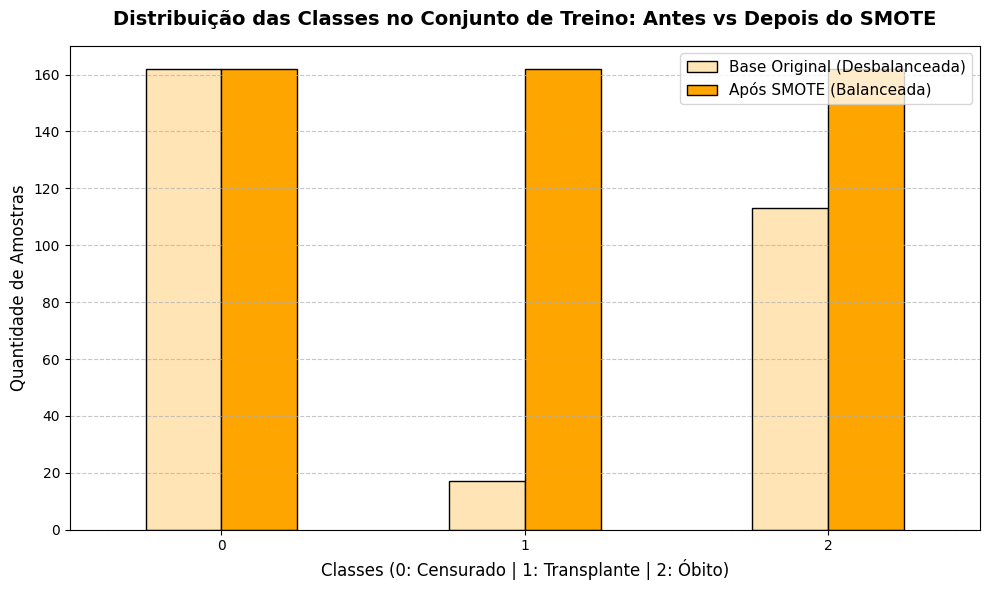

In [63]:
# dataframe temporário pra plotagem
antes_smote = pd.Series(y_train).value_counts().sort_index()
depois_smote = pd.Series(y_train_smote).value_counts().sort_index()

df_dist = pd.DataFrame({
    'Base Original (Desbalanceada)': antes_smote,
    'Após SMOTE (Balanceada)': depois_smote
}, index=[0, 1, 2])

# plotagem e estética do gráfico
plt.figure(figsize=(10, 6))
df_dist.plot(kind='bar', ax=plt.gca(), color=['moccasin', 'orange'], edgecolor='black')

plt.title('Distribuição das Classes no Conjunto de Treino: Antes vs Depois do SMOTE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Classes (0: Censurado | 1: Transplante | 2: Óbito)', fontsize=12)
plt.ylabel('Quantidade de Amostras', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()

### 7.2 Comparativo de Desempenho dos Modelos (F1-Score Macro)
A acurácia geral pode ser uma métrica ilusória em bases de dados desbalanceadas, pois um modelo pode atingir uma alta taxa de acerto apenas ignorando as classes minoritárias. Portanto, utilizamos o **F1-Score Macro**, que calcula a média harmônica entre precisão e revocação para cada classe com pesos iguais, penalizando modelos que falham nas classes com menos amostras.

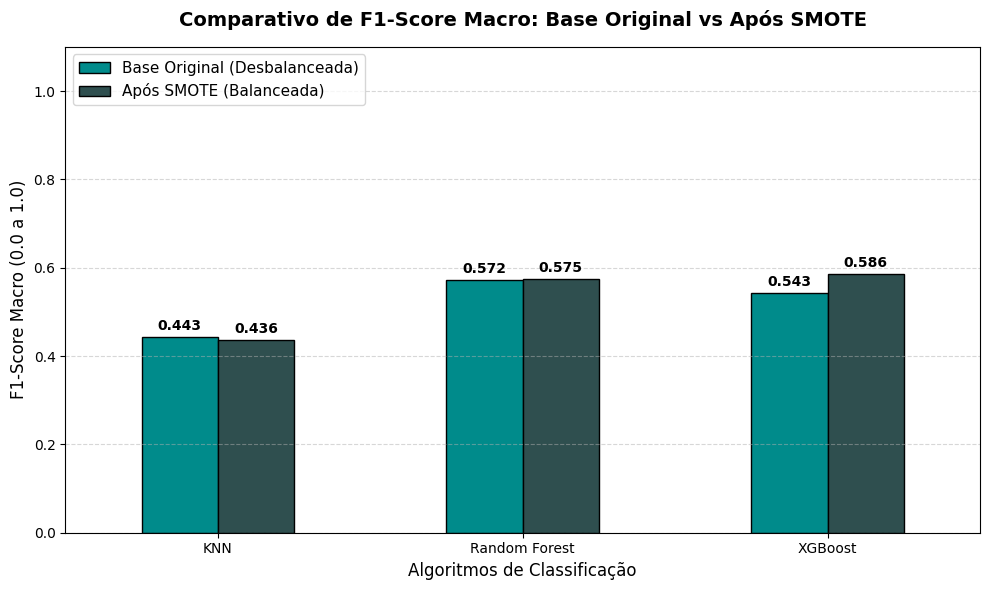

In [64]:
# coleta dos valores de F1-Score Macro de cada modelo treinado antes
f1_original = [
    f1_score(y_test, y_pred_knn, average='macro', zero_division=0),
    f1_score(y_test, y_pred_rf, average='macro', zero_division=0),
    f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)
]

f1_smote = [
    f1_score(y_test, y_pred_knn_smote, average='macro', zero_division=0),
    f1_score(y_test, y_pred_rf_smote, average='macro', zero_division=0),
    f1_score(y_test, y_pred_xgb_smote, average='macro', zero_division=0)
]

# organização em um dataframe para plotar
modelos = ['KNN', 'Random Forest', 'XGBoost']
df_f1 = pd.DataFrame({
    'Base Original (Desbalanceada)': f1_original,
    'Após SMOTE (Balanceada)': f1_smote
}, index=modelos)

# plotagem e estética do gráfico
plt.figure(figsize=(10, 6))
ax = df_f1.plot(kind='bar', ax=plt.gca(), color=['darkcyan', 'darkslategray'], edgecolor='black')

plt.title('Comparativo de F1-Score Macro: Base Original vs Após SMOTE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Algoritmos de Classificação', fontsize=12)
plt.ylabel('F1-Score Macro (0.0 a 1.0)', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.3f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()

### 7.3 Comparativo de Acurácia Global: Base Original vs Após SMOTE
Neste bloco, analisamos a acurácia global obtida pelos três classificadores em ambos os experimentos. Esta etapa é fundamental para contrastar com o F1-Score Macro, evidenciando como o balanceamento artificial por meio do SMOTE redistribui o foco dos algoritmos, muitas vezes reduzindo a acurácia global para melhorar a sensibilidade do modelo em relação às classes menos representadas.

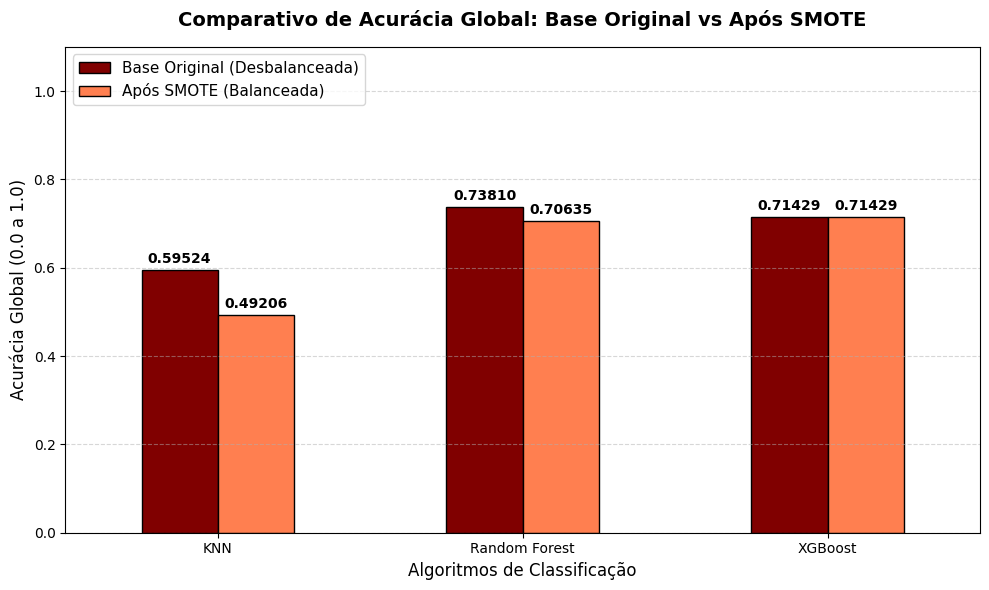

In [65]:
# coleta dos valores de acurácia de cada modelo nos dois experimentos
acc_original = [
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_rf),
    accuracy_score(y_test, y_pred_xgb)
]

acc_smote = [
    accuracy_score(y_test, y_pred_knn_smote),
    accuracy_score(y_test, y_pred_rf_smote),
    accuracy_score(y_test, y_pred_xgb_smote)
]

# organização em um dataframe para plotar
modelos = ['KNN', 'Random Forest', 'XGBoost']
df_acc = pd.DataFrame({
    'Base Original (Desbalanceada)': acc_original,
    'Após SMOTE (Balanceada)': acc_smote
}, index=modelos)

# plotagem e estética do gráfico
plt.figure(figsize=(10, 6))
ax = df_acc.plot(kind='bar', ax=plt.gca(), color=['maroon', 'coral'], edgecolor='black')

plt.title('Comparativo de Acurácia Global: Base Original vs Após SMOTE', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Algoritmos de Classificação', fontsize=12)
plt.ylabel('Acurácia Global (0.0 a 1.0)', fontsize=12)
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(fontsize=11, loc='upper left')

for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.5f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points',
                    fontsize=10, fontweight='bold')

plt.tight_layout()